# BİL403-503 Sosyal Ağlar - Dönem Projesi
## Zachary Karate Kulübü Ağının Yapısal ve Topluluk Analizi

**Öğrenci:** Barış Emre Ahi  
**Öğrenci No:** 221101045  

Bu notebook, rapordaki bütün sayısal sonuçları baştan üretir. Veri, NetworkX'in
`karate_club_graph()` fonksiyonuyla dağıtılan ve Zachary'nin gerçek saha
çalışmasına dayanan 34 kişilik sosyal ağdır.

> Gerekirse bağımlılıklar şu komutla kurulabilir:
> `pip install networkx pandas numpy matplotlib scipy scikit-learn`

### 1. Kütüphaneler ve yeniden üretilebilirlik

Analiz; ağ ölçümleri için NetworkX, veri tabloları için pandas, istatistiksel
testler için SciPy ve görselleştirme için Matplotlib kullanır. Sabit yerleşim
tohumu, ağ çiziminin her çalıştırmada aynı görünmesini sağlar.

In [1]:
# Temel bilimsel Python kütüphaneleri
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

SEED = 42
OUTPUT_DIR = Path("analiz_ciktilari")
OUTPUT_DIR.mkdir(exist_ok=True)

print("NetworkX sürümü:", nx.__version__)

NetworkX sürümü: 3.4.2


### 2. Verinin yüklenmesi ve ağın tipi

Düğümler kulüp üyelerini, kenarlar Zachary'nin gözlediği sosyal etkileşimleri
temsil eder. Ağ yönsüz, ağırlıksız ve basittir: ilişkinin yönü veya yoğunluğu
modellenmemiş, öz-ilmek ve paralel kenar kullanılmamıştır.

In [2]:
# NetworkX içindeki doğrulanmış Zachary Karate Kulübü verisini yükle.
G = nx.karate_club_graph()

network_type = {
    "Yönlü mü?": G.is_directed(),
    "Çoklu ağ mı?": G.is_multigraph(),
    "Ağırlıklı mı?": nx.is_weighted(G),
}
network_type

{'Yönlü mü?': False, 'Çoklu ağ mı?': False, 'Ağırlıklı mı?': True}

### 3. Temel ağ ölçümleri

In [3]:
# Zorunlu ölçümler: düğüm/kenar sayısı, yoğunluk, derece, kümelenme ve bileşenler.
degrees = dict(G.degree())
degree_values = np.array(list(degrees.values()), dtype=float)
component_sizes = sorted(
    [len(component) for component in nx.connected_components(G)],
    reverse=True,
)

summary = pd.Series({
    "Düğüm sayısı (order)": G.number_of_nodes(),
    "Kenar sayısı (size)": G.number_of_edges(),
    "Yoğunluk": nx.density(G),
    "Ortalama derece": degree_values.mean(),
    "Medyan derece": np.median(degree_values),
    "En küçük derece": degree_values.min(),
    "En büyük derece": degree_values.max(),
    "Ortalama kümelenme": nx.average_clustering(G),
    "Geçişlilik (transitivity)": nx.transitivity(G),
    "Bileşen sayısı": len(component_sizes),
    "Bileşen boyutları": component_sizes,
    "Ortalama en kısa yol": nx.average_shortest_path_length(G),
    "Çap": nx.diameter(G),
    "Derece uyumluluğu": nx.degree_assortativity_coefficient(G),
})
summary

Düğüm sayısı (order)               34
Kenar sayısı (size)                78
Yoğunluk                     0.139037
Ortalama derece              4.588235
Medyan derece                     3.0
En küçük derece                   1.0
En büyük derece                  17.0
Ortalama kümelenme           0.570638
Geçişlilik (transitivity)    0.255682
Bileşen sayısı                      1
Bileşen boyutları                [34]
Ortalama en kısa yol           2.4082
Çap                                 5
Derece uyumluluğu           -0.475613
dtype: object

Yoğunluğun 0,139 olması, mümkün kenarların yaklaşık %13,9'unun gözlendiğini
gösterir. Tek bileşen bulunması bütün üyelerin doğrudan veya dolaylı biçimde
birbirine erişebildiği anlamına gelir.

,Derece,Düğüm sayısı
0,1,1
1,2,11
2,3,6
3,4,6
4,5,3
5,6,2
6,9,1
7,10,1
8,12,1
9,16,1


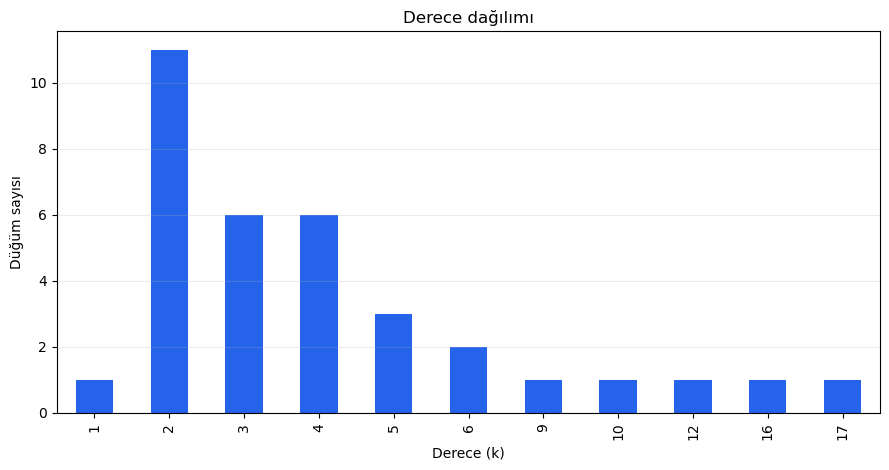

In [4]:
# Derece dağılımını frekans tablosu ve sütun grafiğiyle incele.
degree_counts = Counter(degrees.values())
degree_distribution = pd.DataFrame(
    sorted(degree_counts.items()),
    columns=["Derece", "Düğüm sayısı"],
)
display(degree_distribution)

ax = degree_distribution.plot.bar(
    x="Derece",
    y="Düğüm sayısı",
    color="#2563EB",
    figsize=(9, 4.8),
    legend=False,
)
ax.set_title("Derece dağılımı")
ax.set_xlabel("Derece (k)")
ax.set_ylabel("Düğüm sayısı")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 4. Yerel kümelenme ve merkezilik

In [5]:
# Her düğüm için yerel yapı ve dört farklı merkezilik ölçüsü hesapla.
clustering = nx.clustering(G)
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, normalized=True)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=2000)

node_metrics = pd.DataFrame({
    "Düğüm": [node + 1 for node in G.nodes()],
    "Gerçek grup": [G.nodes[node]["club"] for node in G.nodes()],
    "Derece": [degrees[node] for node in G.nodes()],
    "Kümelenme": [clustering[node] for node in G.nodes()],
    "Derece merkeziliği": [degree_centrality[node] for node in G.nodes()],
    "Aradalık merkeziliği": [betweenness[node] for node in G.nodes()],
    "Yakınlık merkeziliği": [closeness[node] for node in G.nodes()],
    "Özvektör merkeziliği": [eigenvector[node] for node in G.nodes()],
})

node_metrics.sort_values(
    "Aradalık merkeziliği", ascending=False
).head(10).round(4)

,Düğüm,Gerçek grup,Derece,Kümelenme,Derece merkeziliği,Aradalık merkeziliği,Yakınlık merkeziliği,Özvektör merkeziliği
0,1,Mr. Hi,16,0.1500,0.4848,0.4376,0.5690,0.3555
33,34,Officer,17,0.1103,0.5152,0.3041,0.5500,0.3734
32,33,Officer,12,0.1970,0.3636,0.1452,0.5156,0.3087
2,3,Mr. Hi,10,0.2444,0.3030,0.1437,0.5593,0.3172
31,32,Officer,6,0.2000,0.1818,0.1383,0.5410,0.1910
8,9,Mr. Hi,5,0.5000,0.1515,0.0559,0.5156,0.2274
1,2,Mr. Hi,9,0.3333,0.2727,0.0539,0.4853,0.2660
13,14,Mr. Hi,5,0.6000,0.1515,0.0459,0.5156,0.2265
19,20,Mr. Hi,3,0.3333,0.0909,0.0325,0.5000,0.1479
5,6,Mr. Hi,4,0.5000,0.1212,0.0300,0.3837,0.0795


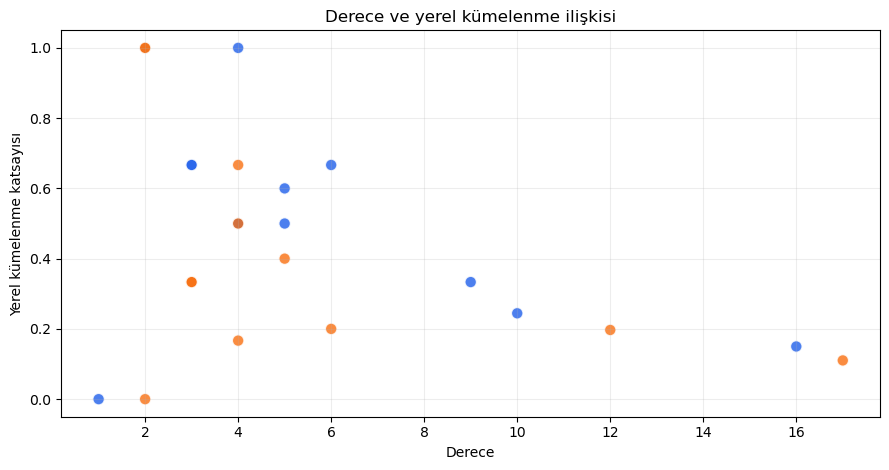

In [6]:
# Derece arttıkça yerel kümelenmenin nasıl değiştiğini gözle.
colors = node_metrics["Gerçek grup"].map({
    "Mr. Hi": "#2563EB",
    "Officer": "#F97316",
})

plt.figure(figsize=(9, 4.8))
plt.scatter(
    node_metrics["Derece"],
    node_metrics["Kümelenme"],
    c=colors,
    s=70,
    alpha=0.82,
    edgecolor="white",
)
plt.title("Derece ve yerel kümelenme ilişkisi")
plt.xlabel("Derece")
plt.ylabel("Yerel kümelenme katsayısı")
plt.grid(alpha=0.22)
plt.tight_layout()
plt.show()

### 5. Girvan-Newman topluluk analizi

In [7]:
# Girvan-Newman algoritmasının ilk bölünmesi iki topluluk üretir.
# Algoritmik etiketler gerçek "Mr. Hi / Officer" etiketleriyle karşılaştırılır.
first_split = next(nx.community.girvan_newman(G))
communities = [set(group) for group in first_split]

true_labels = np.array([
    0 if G.nodes[node]["club"] == "Mr. Hi" else 1
    for node in G.nodes()
])
predicted = np.array([
    0 if node in communities[0] else 1
    for node in G.nodes()
])

# Topluluk numaraları keyfidir; iki olası etiketlemeyi de deneyerek en iyi eşlemeyi seç.
if np.mean(predicted == true_labels) < np.mean((1 - predicted) == true_labels):
    predicted = 1 - predicted

community_results = pd.Series({
    "Topluluk boyutları": [len(group) for group in communities],
    "Modülerlik": nx.community.modularity(G, communities),
    "Doğruluk": np.mean(predicted == true_labels),
    "Ayarlanmış Rand indeksi": adjusted_rand_score(true_labels, predicted),
    "Normalize karşılıklı bilgi": normalized_mutual_info_score(true_labels, predicted),
})
community_results

Topluluk boyutları            [15, 19]
Modülerlik                     0.34766
Doğruluk                      0.941176
Ayarlanmış Rand indeksi       0.771725
Normalize karşılıklı bilgi    0.732378
dtype: object

In [8]:
# Hangi üyelerin gerçek ayrışmadan farklı sınıflandığını göster.
comparison = pd.DataFrame({
    "Düğüm": [node + 1 for node in G.nodes()],
    "Gerçek grup": ["Mr. Hi" if value == 0 else "Officer" for value in true_labels],
    "Tahmin": ["Mr. Hi" if value == 0 else "Officer" for value in predicted],
})
comparison["Doğru mu?"] = comparison["Gerçek grup"] == comparison["Tahmin"]
comparison.loc[~comparison["Doğru mu?"]]

,Düğüm,Gerçek grup,Tahmin,Doğru mu?
2,3,Mr. Hi,Officer,False
8,9,Mr. Hi,Officer,False


### 6. İstatistiksel sınamalar

In [9]:
# 1) İki gerçek grubun derece dağılımları farklı mı?
hi_degrees = node_metrics.loc[
    node_metrics["Gerçek grup"] == "Mr. Hi", "Derece"
]
officer_degrees = node_metrics.loc[
    node_metrics["Gerçek grup"] == "Officer", "Derece"
]
mw = mannwhitneyu(hi_degrees, officer_degrees, alternative="two-sided")

# 2) Derece ile köprü rolünü ölçen aradalık merkeziliği birlikte artıyor mu?
rho = spearmanr(
    node_metrics["Derece"],
    node_metrics["Aradalık merkeziliği"],
)

statistical_results = pd.Series({
    "Mann-Whitney U": mw.statistic,
    "Mann-Whitney p": mw.pvalue,
    "Spearman rho": rho.statistic,
    "Spearman p": rho.pvalue,
})
statistical_results

Mann-Whitney U    1.615000e+02
Mann-Whitney p    5.608523e-01
Spearman rho      9.049410e-01
Spearman p        2.053829e-13
dtype: float64

Mann-Whitney sonucu iki grubun derece dağılımlarında anlamlı bir fark
göstermemektedir. Buna karşılık derece ile aradalık merkeziliği arasındaki çok
güçlü ve anlamlı pozitif ilişki, çok bağlantılı üyelerin aynı zamanda gruplar
arası yollar üzerinde köprü olma eğilimini destekler. Küçük örneklem nedeniyle
bu sonuçlar keşifsel yorumlanmalıdır.

### 7. Ağ görselleştirmesi

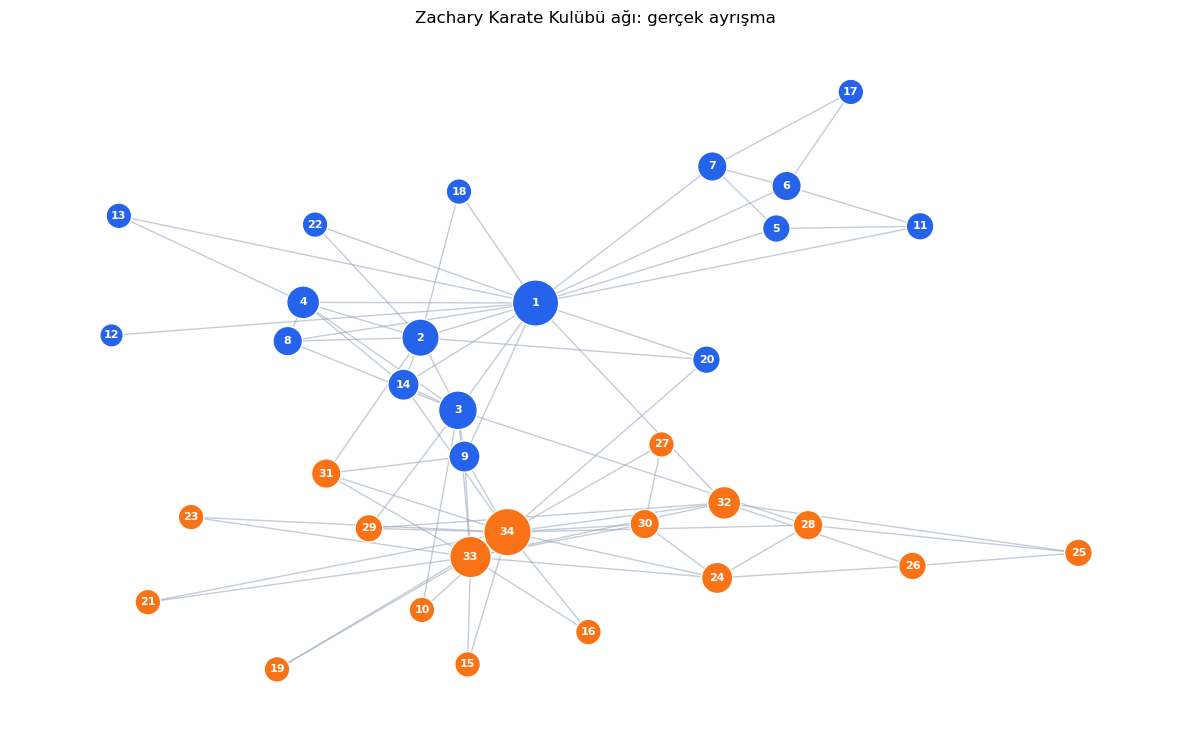

In [10]:
# Düğüm rengi gerçek grubu, düğüm boyutu dereceyi temsil eder.
positions = nx.spring_layout(G, seed=SEED, k=0.62)
node_colors = [
    "#2563EB" if G.nodes[node]["club"] == "Mr. Hi" else "#F97316"
    for node in G.nodes()
]
node_sizes = [230 + 55 * degrees[node] for node in G.nodes()]

plt.figure(figsize=(12, 7.5))
nx.draw_networkx_edges(
    G, positions, edge_color="#94A3B8", alpha=0.55, width=1.0
)
nx.draw_networkx_nodes(
    G,
    positions,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="white",
    linewidths=1.0,
)
nx.draw_networkx_labels(
    G,
    positions,
    labels={node: str(node + 1) for node in G.nodes()},
    font_size=8,
    font_color="white",
    font_weight="bold",
)
plt.title("Zachary Karate Kulübü ağı: gerçek ayrışma")
plt.axis("off")
plt.tight_layout()
plt.show()

### 8. Sonuçların dışa aktarılması

In [11]:
# Raporun yeniden üretilebilirliği için düğüm tablosunu ve ağı kaydet.
node_metrics["GN topluluğu"] = predicted + 1
node_metrics.to_csv(
    OUTPUT_DIR / "dugum_olcumleri.csv",
    index=False,
    encoding="utf-8-sig",
)
nx.write_graphml(G, OUTPUT_DIR / "karate_kulubu.graphml")

print("Kaydedilen dosyalar:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path)

Kaydedilen dosyalar:
- analiz_ciktilari\dugum_olcumleri.csv
- analiz_ciktilari\karate_kulubu.graphml


## Kısa sonuç

Ağ seyrek fakat bütünüyle bağlantılıdır. Derece dağılımında az sayıdaki merkez
üyeye karşı çok sayıda düşük dereceli üye vardır. Düğüm 1 ve 34 hem derece hem
aradalık açısından baskındır. Girvan-Newman'ın iki topluluklu bölümü gerçek
ayrışmayı %94,1 doğrulukla yeniden üretmiştir. Bu, topluluk sınırlarının yalnızca
üyelik etiketlerinde değil, bağlantı örüntüsünde de belirgin olduğunu gösterir.